# VJeaNETte Reproducibility Notebook

## 1. Project overview 

### VJeaNETte inference reproducibility

This notebook demonstrates:
- loading trained UNet1D model
- FASTQ preprocessing
- V/J/CDR3 inference
- running the full pipeline

The goal is to reproduce inference results from the paper/project.

## 2. Imports and environment

In [1]:
import argparse
import csv
import logging
import time

import mmap
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import IterableDataset
from vjeanette.utils import select_best_strand, reverse_complement
from vjeanette.config import DEFAULT_THRESHOLDS

In [2]:
import sys
import torch

print(sys.version)
print(torch.__version__)

3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
2.5.1+cu121


## 3. Constants and configuration

### Global constants and thresholds

In [3]:
MAX_LEN = 512

RC_TABLE = torch.tensor([3,2,1,0,4,5], dtype=torch.uint8)

DEFAULT_THRESHOLDS = {
    "v_exist": 0.02,
    "j_exist": 0.02,
    "cdr_exist": 0.02,
    "mask": 0.04
}

## 4. FASTQ preprocessing

### FASTQ streaming dataset

The dataset implementation uses:

- memory mapped FASTQ reading (`mmap`)
- iterable dataset design
- multithreaded workers
- byte-level nucleotide encoding

This allows efficient processing of very large sequencing datasets.

In [4]:
CHAR_MAP = np.full(256, 4, dtype=np.uint8)

CHAR_MAP[ord("A")] = 0
CHAR_MAP[ord("C")] = 1
CHAR_MAP[ord("G")] = 2
CHAR_MAP[ord("T")] = 3
CHAR_MAP[ord("N")] = 4
CHAR_MAP[ord("P")] = 5

In [5]:
def seq_to_indices_bytes(seq_bytes):
    arr = np.frombuffer(seq_bytes, dtype=np.uint8)
    return CHAR_MAP[arr]
def filling_bytes(seq_bytes):
    seq = seq_bytes[:MAX_LEN]
    if len(seq) < MAX_LEN:
        seq += b"P" * (MAX_LEN - len(seq))
    return seq


In [6]:

class FastqDataset(IterableDataset): 

    def __init__(self, path, batch_size, num_workers):
        self.path = path
        self.batch_size = batch_size
        self.num_workers = num_workers

    def parse_fastq(self, worker_id):

        f = open(self.path, "rb")
        mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)

        size = mm.size()
        chunk = size // self.num_workers

        start = worker_id * chunk
        end = size if worker_id == self.num_workers-1 else (worker_id+1)*chunk

        mm.seek(start)

        if start != 0:
            mm.readline()
            while True:
                pos = mm.tell()
                line = mm.readline()
                if not line:
                    break
                if line.startswith(b'@'):
                    mm.seek(pos)
                    break

        batch = []
        ids = []

        while mm.tell() < end:

            header = mm.readline()
            if not header:
                break

            seq = mm.readline().rstrip()
            mm.readline()
            mm.readline()

            read_id = header[1:].split()[0].decode()

            seq = filling_bytes(seq)

            batch.append(seq_to_indices_bytes(seq))
            ids.append(read_id)

            if len(batch) == self.batch_size:
                yield torch.from_numpy(np.stack(batch)).long(), ids
                batch, ids = [], []

        if batch:
            yield torch.from_numpy(np.stack(batch)).long(), ids

        mm.close()
        f.close()

    def __iter__(self):

        worker_info = torch.utils.data.get_worker_info()

        if worker_info is None:
            worker_id = 0
        else:
            worker_id = worker_info.id

        yield from self.parse_fastq(worker_id)

## 5. CUDA setup

In [7]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: cuda


## 6. UNet architecture

### Model architecture

The model is based on a 1D U-Net encoder-decoder architecture
with separate heads for:
- V segment
- J segment
- CDR3 region

In [8]:
class UNet1D_Embed(nn.Module):
    def __init__(self, embed_dim=32, out_channels=1, features=[8,16,64,64]):
        super().__init__()
        PADDING_IDX = 5
        self.embed = nn.Embedding(num_embeddings=6, embedding_dim=embed_dim, padding_idx=PADDING_IDX)
        
        in_channels = embed_dim
        
        # Encoder
        self.enc1 = self._encoder_block(in_channels, features[0])
        self.enc2 = self._encoder_block(features[0], features[1])
        self.enc3 = self._encoder_block(features[1], features[2])
        self.enc4 = self._encoder_block(features[2], features[3])
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv1d(features[3], features[3]*2, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[3]*2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(features[3]*2, features[3]*2, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[3]*2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )
        
        # Decoder
        self.up4 = nn.ConvTranspose1d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.dec4 = self._decoder_block(features[3]+features[2], features[2])
        
        self.up3 = nn.ConvTranspose1d(features[2], features[2], kernel_size=2, stride=2)
        self.dec3 = self._decoder_block(features[2]+features[1], features[1])
        
        self.up2 = nn.ConvTranspose1d(features[1], features[1], kernel_size=2, stride=2)
        self.dec2 = self._decoder_block(features[1]+features[0], features[0])
        
        self.up1 = nn.ConvTranspose1d(features[0], features[0], kernel_size=2, stride=2)
        
        self.final_conv = nn.Sequential(
            nn.Conv1d(features[0], features[0], kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv1d(features[0], features[0], kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(features[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )
        
        self.v_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size=1)
        )
        self.j_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size=1)
        )
        self.cdr_head = nn.Sequential(
            nn.Conv1d(features[0], features[0]//2, kernel_size = 1),
            nn.ReLU(inplace = True),
            nn.Conv1d(features[0]//2, out_channels, kernel_size = 1)
        )
        
    
    def _encoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Conv1d(out_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.MaxPool1d(2)
        )
    
    def _decoder_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Conv1d(out_channels, out_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35)
        )
    
    def forward(self, x):
        """
        x: [B, L] LongTensor индексы 0..5
        """
        x = self.embed(x).transpose(1, 2)  # [B, embed_dim, L]
        
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        
        b = self.bottleneck(e4)
        
        d4 = self.up4(b)
        d4 = torch.cat((d4, e3), dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        d3 = torch.cat((d3, e2), dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat((d2, e1), dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = self.final_conv(d1)
        
        v_out = self.v_head(d1)
        j_out = self.j_head(d1)
        cdr_out = self.cdr_head(d1)
        
        return cdr_out.squeeze(1), v_out.squeeze(1), j_out.squeeze(1)

## 7. Utility functions

In [9]:
def reverse_complement(x):
    """Reverse complement"""
    return RC_TABLE.to(x.device)[x].flip(1)

def get_intervals_fast(probs, thr):
    """Fast intervals defining"""
    mask = probs > thr
    
    any_mask = mask.any(1)
    mask_int = mask.to(torch.int8)
    starts = torch.argmax(mask_int, dim=1)
    ends = mask.size(1) - torch.argmax(mask_int.flip(1), dim=1) - 1
    
    starts[~any_mask] = -1
    ends[~any_mask] = -1
    
    return starts, ends

def calculate_scores(has_v, has_j, max_v, max_j):
    """Score calculation"""
    return 2*has_v.float() + 2*has_j.float() + max_v + max_j

def select_best_strand(vf, vr, jf, jr, has_vf, has_vr, has_jf, has_jr):
    """Select best strand (forward/reverse)"""
    max_vf = vf.max(1).values
    max_vr = vr.max(1).values
    max_jf = jf.max(1).values
    max_jr = jr.max(1).values
    
    score_f = calculate_scores(has_vf, has_jf, max_vf, max_jf)
    score_r = calculate_scores(has_vr, has_jr, max_vr, max_jr)
    
    return score_f >= score_r, max_vf, max_vr, max_jf, max_jr

## 8. Inference pipeline

### Inference pipeline

The inference runner:
1. loads FASTQ reads
2. generates reverse complements
3. predicts V/J/CDR3 probabilities
4. selects the best strand
5. exports results to CSV

In [31]:
IDX_TO_BYTE = np.array(
    [b'A', b'C', b'G', b'T', b'N', b'P'],
    dtype='S1'
)


@torch.jit.script
def sequence_score_smoothed(
    logits: torch.Tensor,
    lengths: torch.Tensor,
    window_size: int
) -> torch.Tensor:
    """
    Maximum average probability inside a valid window.

    logits:  [B, L]
    lengths: [B]

    return: [B]
    """

    probs = torch.sigmoid(logits).unsqueeze(1)

    smoothed = F.avg_pool1d(
        probs,
        kernel_size=window_size,
        stride=1
    ).squeeze(1)

    positions = torch.arange(
        smoothed.shape[1],
        device=logits.device
    ).unsqueeze(0)

    valid = (
        positions + window_size
        <= lengths.unsqueeze(1)
    )

    smoothed = smoothed.masked_fill(
        ~valid,
        -torch.inf
    )

    return smoothed.max(dim=1).values


class InferenceRunner:

    def __init__(
        self,
        model,
        device="cuda",
        thresholds=None,
        use_amp=True,
        compiled=False
    ):

        self.model = model
        self.device = torch.device(device)

        self.thresholds = (
            thresholds
            if thresholds is not None
            else DEFAULT_THRESHOLDS
        )

        self.use_amp = (
            use_amp
            and self.device.type == "cuda"
        )

        self.compiled = compiled

        self.logger = self._setup_logger()

        self.model = self.model.to(self.device)
        self.model.eval()

    def _setup_logger(self):

        logger = logging.getLogger("inference")
        logger.setLevel(logging.INFO)

        return logger

    def add_log_handler(self, log_file):

        handler = logging.FileHandler(log_file)

        handler.setFormatter(
            logging.Formatter(
                "%(asctime)s | %(message)s"
            )
        )

        self.logger.addHandler(handler)
        self.logger.propagate = False


    def _process_batch(
        self,
        x,
        read_ids
    ):
        """
        Process one batch.

        Returns:
            fasta_records
        """

        bs = len(read_ids)

        # ==================================================
        # 1. CPU -> GPU
        # ==================================================

        x = x.to(
            self.device,
            non_blocking=True
        )

        # Real sequence length before padding
        lengths = (
            x != 5
        ).sum(dim=1)

        # ==================================================
        # 2. Reverse complement on GPU
        # ==================================================

        x_rc = reverse_complement(x)

        x_both = torch.cat(
            (x, x_rc),
            dim=0
        )

        lengths_both = torch.cat(
            (lengths, lengths),
            dim=0
        )

        # ==================================================
        # 3. Model inference
        # ==================================================

        with torch.inference_mode():

            if self.use_amp:

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    cdr3_logits, v_logits, j_logits = (
                        self.model(x_both)
                    )

            else:

                cdr3_logits, v_logits, j_logits = (
                    self.model(x_both)
                )

        # ==================================================
        # 4. Sequence-level scores
        # ==================================================

        # V
        v_score = sequence_score_smoothed(
            v_logits,
            lengths_both,
            window_size=15
        )

        # J
        j_score = sequence_score_smoothed(
            j_logits,
            lengths_both,
            window_size=10
        )

        # CDR3
        cdr_score = sequence_score_smoothed(
            cdr3_logits,
            lengths_both,
            window_size=6
        )

        # ==================================================
        # 5. Forward / reverse
        # ==================================================

        vf_score = v_score[:bs]
        vr_score = v_score[bs:]

        jf_score = j_score[:bs]
        jr_score = j_score[bs:]

        cdrf_score = cdr_score[:bs]
        cdrr_score = cdr_score[bs:]

        # ==================================================
        # 6. Existence predictions
        # ==================================================

        has_vf = (
            vf_score
            > self.thresholds["v_exist"]
        )

        has_vr = (
            vr_score
            > self.thresholds["v_exist"]
        )

        has_jf = (
            jf_score
            > self.thresholds["j_exist"]
        )

        has_jr = (
            jr_score
            > self.thresholds["j_exist"]
        )

        has_cdrf = (
            cdrf_score
            > self.thresholds["cdr_exist"]
        )

        has_cdrr = (
            cdrr_score
            > self.thresholds["cdr_exist"]
        )

        # ==================================================
        # 7. Select best strand
        # ==================================================

        choose_f = select_best_strand(
            vf_score,
            vr_score,
            jf_score,
            jr_score,
            has_vf,
            has_vr,
            has_jf,
            has_jr
        )

        f = choose_f.bool()

        # ==================================================
        # 8. Select predictions
        # ==================================================

        has_v = torch.where(
            f,
            has_vf,
            has_vr
        )

        has_j = torch.where(
            f,
            has_jf,
            has_jr
        )

        has_cdr3 = torch.where(
            f,
            has_cdrf,
            has_cdrr
        )

        # ==================================================
        # 9. SCORE
        #
        # Formula unchanged
        # ==================================================

        score = torch.where(

            f,

            2 * has_vf.float()
            + 2 * has_jf.float()
            + vf_score
            + jf_score,

            2 * has_vr.float()
            + 2 * has_jr.float()
            + vr_score
            + jr_score
        )

        # ==================================================
        # 10. Keep only positive reads
        # ==================================================

        keep = (
            has_v
            | has_j
            | has_cdr3
        )

        indices = torch.nonzero(
            keep,
            as_tuple=False
        ).flatten()

        if indices.numel() == 0:

            return []

        # ==================================================
        # 11. Move only retained reads to CPU
        # ==================================================

        indices_cpu = (
            indices
            .cpu()
            .numpy()
        )

        score_keep_cpu = (
            score[indices]
            .float()
            .cpu()
            .numpy()
        )

        v_keep_cpu = (
            has_v[indices]
            .cpu()
            .numpy()
        )

        j_keep_cpu = (
            has_j[indices]
            .cpu()
            .numpy()
        )

        cdr_keep_cpu = (
            has_cdr3[indices]
            .cpu()
            .numpy()
        )

        # ==================================================
        # 12. Select strand sequence
        # ==================================================

        selected_x = torch.where(
            f[indices, None],
            x[indices],
            x_rc[indices]
        )

        selected_x = (
            selected_x
            .cpu()
            .numpy()
        )

        # ==================================================
        # 13. FASTA output
        # ==================================================

        fasta_output = []

        for k, idx in enumerate(indices_cpu):

            sequence = (
                IDX_TO_BYTE[selected_x[k]]
                .tobytes()
                .rstrip(b'P')
                .decode("ascii")
            )

            header = (
                f">{read_ids[idx]} "
                f"score={score_keep_cpu[k]:.6f} "
                f"has_v={int(v_keep_cpu[k])} "
                f"has_j={int(j_keep_cpu[k])} "
                f"has_cdr3={int(cdr_keep_cpu[k])}"
            )

            fasta_output.append(
                header
                + "\n"
                + sequence
                + "\n"
            )

        return fasta_output


    def run(
        self,
        fastq_file,
        output_fasta,
        batch_size=32768,
        num_workers=1
    ):

        self.logger.info(
            f"PARAMETERS:\n"
            f"Fastq file: {fastq_file}\n"
            f"Output FASTA: {output_fasta}\n"
            f"Batch size: {batch_size}\n"
            f"Workers: {num_workers}\n"
            f"Device: {self.device}\n"
            f"AMP: {self.use_amp}\n"
            f"Compile: {self.compiled}\n"
        )

        dataset = FastqDataset(
            fastq_file,
            batch_size,
            num_workers
        )

        loader_kwargs = dict(

            dataset=dataset,

            batch_size=None,

            num_workers=num_workers,

            pin_memory=(
                self.device.type == "cuda"
            )
        )

        if num_workers > 0:

            loader_kwargs.update({

                "persistent_workers": True,

                "prefetch_factor": 2
            })

        loader = DataLoader(
            **loader_kwargs
        )

        start = time.perf_counter()

        total_reads = 0
        kept_reads = 0

        # ==================================================
        # FASTA OUTPUT
        # ==================================================

        with open(
            output_fasta,
            "w",
            buffering=1024 * 1024
        ) as fasta_file:

            for x, read_ids in loader:

                total_reads += len(
                    read_ids
                )

                fasta_records = (
                    self._process_batch(
                        x,
                        read_ids
                    )
                )

                if fasta_records:

                    fasta_file.writelines(
                        fasta_records
                    )

                    kept_reads += len(
                        fasta_records
                    )

        elapsed = (
            time.perf_counter()
            - start
        )

        speed = (
            total_reads
            / elapsed
        )

        self.logger.info(
            f"TIME: {elapsed:.2f} sec"
        )

        self.logger.info(
            f"READS: {total_reads}"
        )

        self.logger.info(
            f"KEPT: {kept_reads}"
        )

        self.logger.info(
            f"SPEED: {speed:.2f} reads/sec"
        )

        self.logger.info(
            f"OUTPUT FASTA: {output_fasta}"
        )

## 9. Configuration loading

In [32]:
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib

In [33]:
MODEL_PATH = "/path/to/model"

model = UNet1D_Embed().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

print("Model loaded")

Model loaded


## 10. Running Inference

In [34]:
runner = InferenceRunner(
    model=model,
    device=DEVICE,
    thresholds=DEFAULT_THRESHOLDS
)

runner.run(
    fastq_file="/path/to/fastq",
    output_fasta="out_fastq.fasta",
    batch_size=16384,
    num_workers=1
)

INFO:inference:Run inference


## 11.Metrics counting

### 11.1 Fastq parsing

In [17]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


HEADER_RE = re.compile(
    r"^>(\S+)"
    r"\s+score=([0-9.eE+-]+)"
    r"\s+has_v=(\d+)"
    r"\s+has_j=(\d+)"
    r"\s+has_cdr3=(\d+)"
)


def parse_prediction_fasta(path):

    records = []

    with open(path) as f:

        current_header = None
        sequence = []

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                if current_header is not None:

                    m = HEADER_RE.match(current_header)

                    if m is None:
                        raise ValueError(
                            f"Cannot parse FASTA header:\n"
                            f"{current_header}"
                        )

                    records.append({
                        "sequence_id": m.group(1),
                        "score": float(m.group(2)),
                        "pred_v": int(m.group(3)),
                        "pred_j": int(m.group(4)),
                        "pred_cdr3": int(m.group(5)),
                    })

                current_header = line
                sequence = []

            else:
                sequence.append(line)

        if current_header is not None:

            m = HEADER_RE.match(current_header)

            if m is None:
                raise ValueError(
                    f"Cannot parse FASTA header:\n"
                    f"{current_header}"
                )

            records.append({
                "sequence_id": m.group(1),
                "score": float(m.group(2)),
                "pred_v": int(m.group(3)),
                "pred_j": int(m.group(4)),
                "pred_cdr3": int(m.group(5)),
            })

    return pd.DataFrame(records)

### 11.2 Loading ground truth

In [49]:
gt = pd.read_csv("../data/test_5494024_reference.tsv")

gt["has_v_ok"] = (
    gt["has_v"].astype(bool) &
    (gt['best_v_score']>50) & (gt['best_v_identity']>80)
)

gt["has_j_ok"] = (
    gt["has_j"].astype(bool) &
    (gt['best_j_score']>40) & (gt['best_j_identity']>90)
)
gt["has_cdr3_ok"] = (
    gt["has_v_ok"]
    & gt["has_j_ok"]
)

### 11.3 Loading results

In [51]:
pred = parse_prediction_fasta(
    "../out/test_out_5494024_newest.fasta"
)

print(pred.head())
print(f"Predicted reads: {len(pred)}")

      sequence_id     score  pred_v  pred_j  pred_cdr3
0  SRR5494024.151  2.999308       1       0          0
1  SRR5494024.232  3.000236       1       0          0
2  SRR5494024.389  3.035675       0       1          0
3  SRR5494024.414  5.936035       1       1          1
4  SRR5494024.700  2.926546       1       0          0
Predicted reads: 300649


### 11.4 Merging results

In [52]:
df = gt[
    [
        "sequence_id",
        "has_v_ok",
        "has_j_ok",
        "has_cdr3_ok",
        'has_v',
        'has_j',
        'best_v_score',
        'best_j_score',
        'best_v_identity',
        'best_j_identity'
    ]
].copy()

df = df.merge(
    pred[
        [
            "sequence_id",
            "pred_v",
            "pred_j",
            "pred_cdr3",
            "score"
        ]
    ],
    on="sequence_id",
    how="left"
)


In [53]:
df["pred_v"] = df["pred_v"].fillna(0).astype(int)
df["pred_j"] = df["pred_j"].fillna(0).astype(int)
df["pred_cdr3"] = df["pred_cdr3"].fillna(0).astype(int)

### 11.5 Counting metrics

In [54]:
def calculate_metrics(y_true, y_pred):

    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)

    tp = np.sum(y_true & y_pred)
    fp = np.sum(~y_true & y_pred)
    fn = np.sum(y_true & ~y_pred)
    tn = np.sum(~y_true & ~y_pred)

    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else np.nan
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else np.nan
    )

    return {
        "precision": precision,
        "recall": recall,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    }

In [56]:
v_metrics_vjeanette = calculate_metrics(
    df["has_v_ok"],
    df["pred_v"]
)

j_metrics_vjeanette = calculate_metrics(
    df["has_j_ok"],
    df["pred_j"]
)

cdr3_metrics_vjeanette = calculate_metrics(
    df["has_cdr3_ok"],
    df["pred_cdr3"]
)

print("V:")
print(v_metrics_vjeanette)

print("\nJ:")
print(j_metrics_vjeanette)

print("\nCDR3:")
print(cdr3_metrics_vjeanette)

V:
{'precision': np.float64(0.5820295262941946), 'recall': np.float64(0.9424141194462028), 'tp': np.int64(150365), 'fp': np.int64(107981), 'fn': np.int64(9188), 'tn': np.int64(23627482)}

J:
{'precision': np.float64(0.5846235617193422), 'recall': np.float64(0.9936429336188437), 'tp': np.int64(59396), 'fp': np.int64(42201), 'fn': np.int64(380), 'tn': np.int64(23793039)}

CDR3:
{'precision': np.float64(0.7724441386303552), 'recall': np.float64(0.8876565816305297), 'tp': np.int64(42659), 'fp': np.int64(12567), 'fn': np.int64(5399), 'tn': np.int64(23834391)}


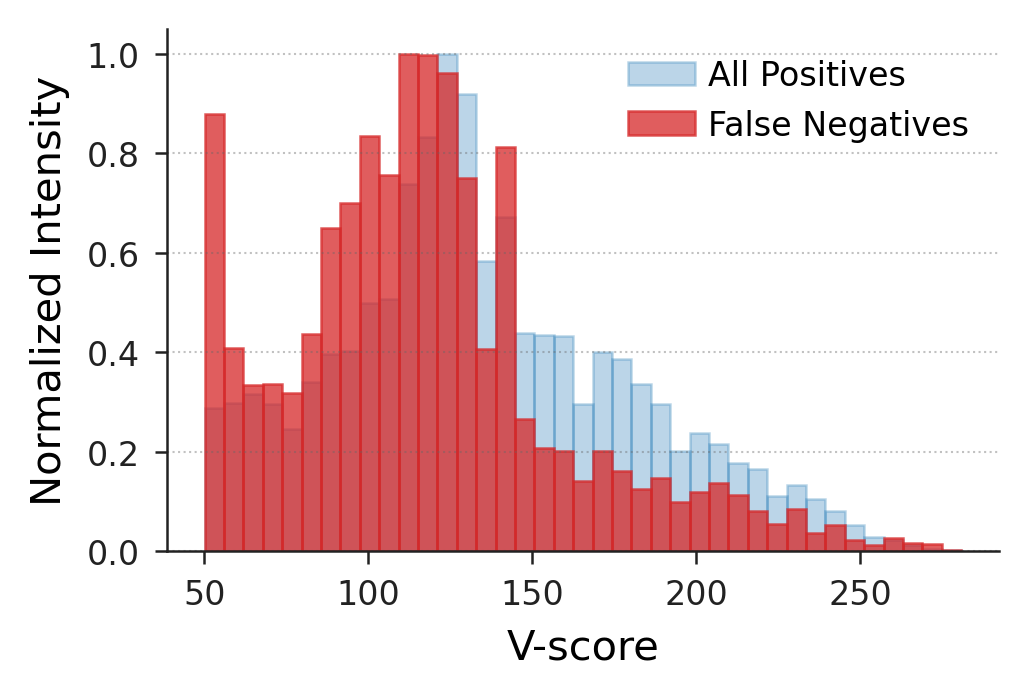

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "sans-serif",     
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,                  
    "axes.labelsize": 10,           
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 11
})

scores_fn = fn["best_v_score"]
scores_all_above_50 = df[df["best_v_score"] > 50]["best_v_score"]

min_score = min(scores_fn.min(), scores_all_above_50.min())
max_score = max(scores_fn.max(), scores_all_above_50.max())
bins = np.linspace(min_score, max_score, 40)  

fig, ax = plt.subplots(figsize=(3.5, 2.4), dpi=300)

counts_fn, _ = np.histogram(scores_fn, bins=bins)
weights_fn = np.ones_like(scores_fn) / (counts_fn.max() if counts_fn.max() > 0 else 1)

counts_all, _ = np.histogram(scores_all_above_50, bins=bins)
weights_all = np.ones_like(scores_all_above_50) / (counts_all.max() if counts_all.max() > 0 else 1)

ax.hist(
    scores_all_above_50,
    bins=bins,
    weights=weights_all,
    alpha=0.3,
    label="All Positives",
    color="#1f77b4", 
    edgecolor="#1f77b4",
    linewidth=0.6
)

ax.hist(
    scores_fn,
    bins=bins,
    weights=weights_fn,
    alpha=0.75,
    label="False Negatives",
    color="#d62728", 
    edgecolor="#d62728",
    linewidth=0.6
)

ax.set_xlabel("V-score", labelpad=4)
ax.set_ylabel("Normalized Intensity", labelpad=4)

ax.legend(loc="upper right", frameon=False, handletextpad=0.4, columnspacing=0.5)

ax.grid(axis="y", linestyle=":", alpha=0.4, color="#666666", linewidth=0.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#222222")
    ax.spines[spine].set_linewidth(0.6)

ax.tick_params(direction="out", length=3, width=0.6, colors="#222222")

plt.tight_layout()

plt.savefig('fig_fn_v.pdf', format='pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig('fig_fn_v.png', dpi=800, bbox_inches='tight', pad_inches=0.02)
plt.show()

### 11.6 Testing Thresholds

In [214]:
evaluation = pd.read_csv('../evaluation_10245671_newest.csv')

In [ ]:
df = gt.merge(
    evaluation,
    on="sequence_id",
    how="inner"
)


In [220]:
import matplotlib.pyplot as plt

thresholds = [
    0.001,
    0.003,
    0.005,
    0.01,
    0.03,
    0.05,
    0.1,
    0.2,
    0.3,
    0.5,
    0.7,
    0.9,
    0.95,
    0.96,
    0.97,
    0.98
]
recalls_skin = []
pos_skin =[]
for thr in thresholds:
    pred = df["cdr3_score"] > thr

    tp = (pred & df["has_v_ok"] & df["has_j_ok"]).sum()
    fp = (pred & (~(df["has_v_ok"] & df["has_j_ok"]))).sum()
    fn = (~pred & (df["has_v_ok"] & df["has_j_ok"])).sum()
    tn = (~pred & (~(df["has_v_ok"] & df["has_j_ok"]))).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn +1e-9)

    f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

    recalls_skin.append(recall)
    pos_skin.append(tp/(tp+fp+ fp+tn +1e-9))

for i,k in zip(recalls_skin,pos_skin):
    print(i,k)

0.995407577496844 0.00018915247636753068
0.995407577496844 0.0001892147381039963
0.9951205510904148 0.00018919570814420128
0.9942594718711268 0.00018913761492335096
0.9922502870261216 0.0001890051386216282
0.9919632606196923 0.0001889596290704985
0.9902411021811165 0.0001886395262687375
0.9853616532718182 0.00018773083565103174
0.9801951779560907 0.00018675433274153446
0.9658438576346252 0.00018402702315152922
0.9503444316874425 0.00018107721748358233
0.9302525832373909 0.00017725096280743211
0.9253731343280927 0.00017632195250967281
0.9227898966702288 0.00017582999826029478
0.916475315728784 0.00017462750416551953
0.8711251435129532 0.00016599011792736481


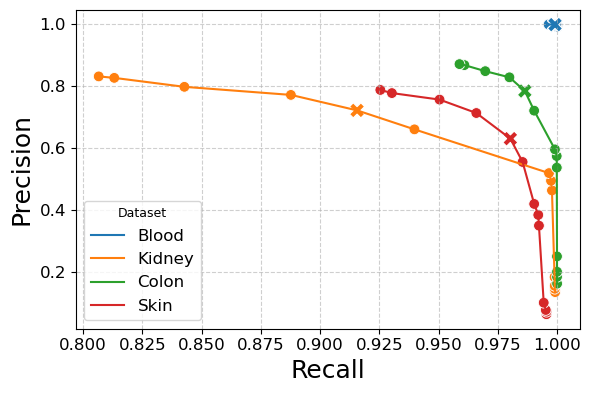

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.rcParams.update({
    "font.family": "sans-serif",    
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,                  
    "axes.labelsize": 18,            
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 11
})
# 1. Добавляем имя датасета
df_blood["Dataset"] = "Blood"
df_kidney["Dataset"] = "Kidney"
df_colon["Dataset"] = "Colon"
df_skin["Dataset"] = "Skin"

dfs = [df_blood.iloc[:-1], df_kidney.iloc[:-1], df_colon.iloc[:-1], df_skin.iloc[:-1]]

normal_points_list = []
special_points_list = []

for df in dfs:
    idx_minus_5 = len(df) - 5

    special_points_list.append(df.iloc[[idx_minus_5]])

    normal_df = df.drop(df.index[idx_minus_5])
    normal_points_list.append(normal_df)

df_all_lines = pd.concat(
    dfs, ignore_index=True
)  
df_normal_dots = pd.concat(normal_points_list, ignore_index=True)
df_special_dots = pd.concat(special_points_list, ignore_index=True) 

plt.figure(figsize=(6, 4))

sns.lineplot(
    data=df_all_lines, x="Recall", y="Position", hue="Dataset", marker=None
)

sns.scatterplot(
    data=df_normal_dots,
    x="Recall",
    y="Position",
    hue="Dataset",
    marker="o",
    s=60,
    legend=False,
)

sns.scatterplot(
    data=df_special_dots,
    x="Recall",
    y="Position",
    hue="Dataset",
    marker="X",
    s=120,
    legend=False,
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig('prec_rec.png', dpi=1200)


### 11.7 Loading Vidjil

In [9]:
import pandas as pd
import numpy as np
from Bio import SeqIO



# Приводим ID к строке
gt["sequence_id"] = gt["sequence_id"].astype(str)


def read_vidjil_fasta(fasta_file):

    ids = set()

    for record in SeqIO.parse(fasta_file, "fasta"):
        rid = record.id

        ids.add(str(rid))

    return ids


vidjil_ids = read_vidjil_fasta(
    "/path/to/fasta"
)

print(f"Vidjil positive reads: {len(vidjil_ids):,}")


gt["pred_v"] = gt["sequence_id"].isin(vidjil_ids)
gt["pred_j"] = gt["sequence_id"].isin(vidjil_ids)
gt["pred_cdr3"] = gt["sequence_id"].isin(vidjil_ids)



def calculate_metrics(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)

    tp = np.sum(y_true & y_pred)
    fp = np.sum(~y_true & y_pred)
    fn = np.sum(y_true & ~y_pred)
    tn = np.sum(~y_true & ~y_pred)

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)

    return {
        "precision": precision,
        "recall": recall,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    }



v_metrics_vidjil = calculate_metrics(
    gt["has_v_ok"],
    gt["pred_v"]
)

j_metrics_vidjil = calculate_metrics(
    gt["has_j_ok"],
    gt["pred_j"]
)

cdr3_metrics_vidjil = calculate_metrics(
    gt["has_cdr3_ok"],
    gt["pred_cdr3"]
)



print("\n" + "=" * 60)
print("VIDJIL METRICS")
print("=" * 60)

print("\nV:")
print(v_metrics_vidjil)

print("\nJ:")
print(j_metrics_vidjil)

print("\nCDR3:")
print(cdr3_metrics_vidjil)

Vidjil positive reads: 4,108,105

VIDJIL METRICS

V:
{'precision': np.float64(0.9999999999999998), 'recall': np.float64(0.9934972094276313), 'tp': np.int64(4108105), 'fp': np.int64(0), 'fn': np.int64(26889), 'tn': np.int64(0)}

J:
{'precision': np.float64(0.9999973223663949), 'recall': np.float64(0.9945959425384614), 'tp': np.int64(4108094), 'fp': np.int64(11), 'fn': np.int64(22321), 'tn': np.int64(4568)}

CDR3:
{'precision': np.float64(0.9999973223663949), 'recall': np.float64(0.9945959425384614), 'tp': np.int64(4108094), 'fp': np.int64(11), 'fn': np.int64(22321), 'tn': np.int64(4568)}


In [27]:
precision_v_vidjil, precision_j_vidjil, precision_cdr_vidjil = v_metrics_vidjil['precision'], j_metrics_vidjil['precision'], cdr3_metrics_vidjil['precision']

In [28]:
recall_v_vidjil, recall_j_vidjil, recall_cdr_vidjil = v_metrics_vidjil['recall'], j_metrics_vidjil['recall'], cdr3_metrics_vidjil['recall']

In [29]:
precision_v_vjeanette, precision_j_vjeanette, precision_cdr_vjeanette = v_metrics_vjeanette['precision'], j_metrics_vjeanette['precision'], cdr3_metrics_vjeanette['precision']

In [30]:
recall_v_vjeanette, recall_j_vjeanette, recall_cdr_vjeanette = v_metrics_vjeanette['recall'], j_metrics_vjeanette['recall'], cdr3_metrics_vjeanette['recall']

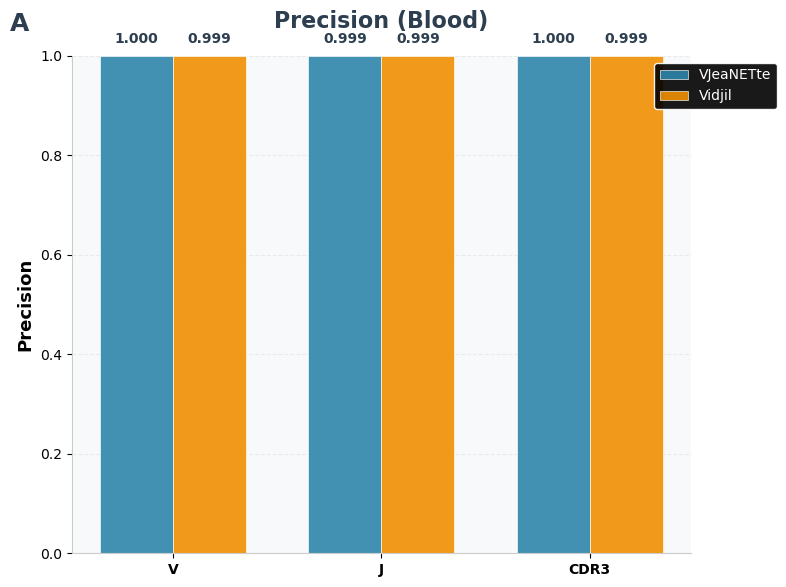

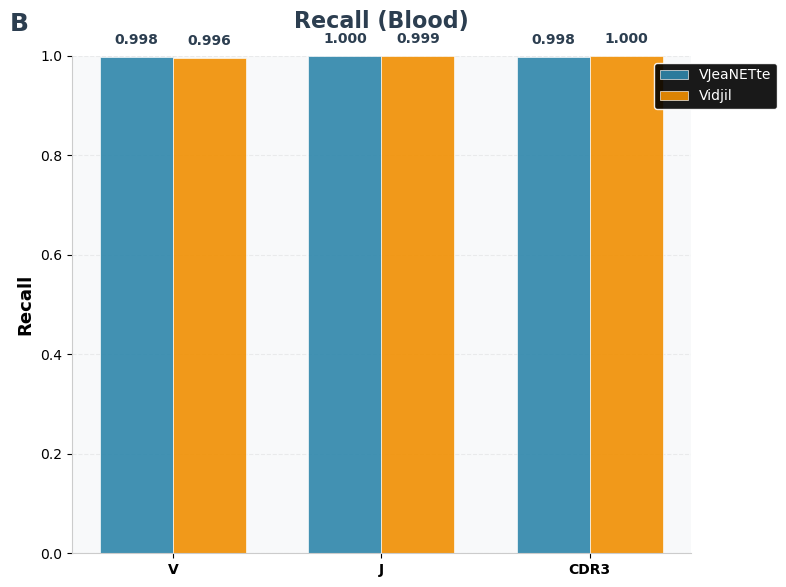

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

colors = ['#2E86AB', '#A23B72', '#F18F01']

# 1. Precision
fig1, ax1 = plt.subplots(figsize=(8, 6), facecolor='white')
ax1.set_facecolor('#f8f9fa')

labels = ["V", "J", "CDR3"]
x = np.arange(len(labels))
width = 0.35

precision_model = [precision_v_vjeanette, precision_j_vjeanette, precision_cdr_vjeanette]
precision_vidjil = [precision_v_vidjil, precision_j_vidjil, precision_cdr_vidjil]

bars1_model = ax1.bar(x - width/2, precision_model, width, label='VJeaNETte', 
                      color=colors[0], alpha=0.9, edgecolor='white', linewidth=0.5)
bars1_vidjil = ax1.bar(x + width/2, precision_vidjil, width, label='Vidjil', 
                       color=colors[2], alpha=0.9, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.set_axisbelow(True)

# Убираем границы (справа и сверху)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')

for bars in [bars1_model, bars1_vidjil]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, 
                fontweight='bold', color='#2c3e50')

ax1.set_title('Precision (Blood)', fontsize=16, fontweight='bold', 
              pad=20, color='#2c3e50')

legend1 = ax1.legend(loc='upper right', frameon=True, fancybox=True, 
                     framealpha=0.9, edgecolor='white', bbox_to_anchor=(1.15, 1.0))
legend1.get_frame().set_facecolor('black')
plt.setp(legend1.get_texts(), color='white')

ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, fontsize=18, 
         fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()  

fig1.savefig('precision_plot_blood.png', transparent=True, dpi=300, bbox_inches='tight')

# 2. Recall
fig2, ax2 = plt.subplots(figsize=(8, 6), facecolor='white')
ax2.set_facecolor('#f8f9fa')

recall_model = [recall_v_vjeanette, recall_j_vjeanette, recall_cdr_vjeanette]
recall_vidjil = [recall_v_vidjil, recall_j_vidjil, recall_cdr_vidjil]

bars2_model = ax2.bar(x - width/2, recall_model, width, label='VJeaNETte', 
                      color=colors[0], alpha=0.9, edgecolor='white', linewidth=0.5)
bars2_vidjil = ax2.bar(x + width/2, recall_vidjil, width, label='Vidjil', 
                       color=colors[2], alpha=0.9, edgecolor='white', linewidth=0.5)

ax2.set_ylabel('Recall', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.set_axisbelow(True)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')

for bars in [bars2_model, bars2_vidjil]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, 
                fontweight='bold', color='#2c3e50')

ax2.set_title('Recall (Blood)', fontsize=16, fontweight='bold', 
              pad=20, color='#2c3e50')

legend2 = ax2.legend(loc='upper right', frameon=True, fancybox=True, 
                     framealpha=0.9, edgecolor='white', bbox_to_anchor=(1.15, 1.0))
legend2.get_frame().set_facecolor('black')
plt.setp(legend2.get_texts(), color='white')

ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes, fontsize=18, 
         fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show() 

fig2.savefig('recall_plot_blood.png', transparent=True, dpi=300, bbox_inches='tight')

### 11.8 Runtime comparison

In [2]:
vidjil = [44497.12,8518.23,5099.43,804.48]
vjeanette = [381.85, 522.99, 346.86, 106.93]
names = ['Skin', 'Colon', 'Kidney', 'Blood']

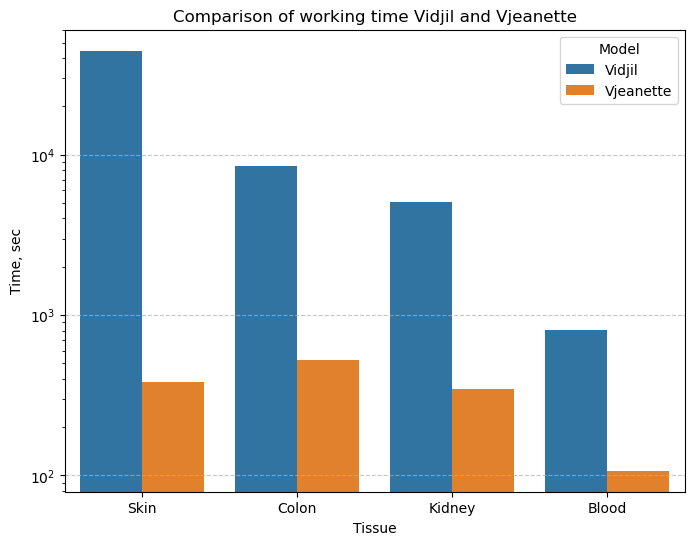

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ваши исходные данные
vidjil = [44497.12, 8518.23, 5099.43, 804.48]
vjeanette = [381.85, 522.99, 346.86, 106.93]
names = ["Skin", "Colon", "Kidney", "Blood"]

data = pd.DataFrame(
    {
        "Tissue": names * 2,
        "Value": vidjil + vjeanette,
        "Model": ["Vidjil"] * 4 + ["Vjeanette"] * 4,
    }
)

plt.figure(figsize=(8, 6))

sns.barplot(x="Tissue", y="Value", hue="Model", data=data)

plt.title("Comparison of working time Vidjil and Vjeanette")
plt.xlabel("Tissue")
plt.ylabel("Time, sec")
plt.grid(axis="y", linestyle="--", alpha=0.7)  
plt.yscale('log')
plt.show()
